In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}/{os.getenv('MYSQL_DATABASE')}"
)



In [6]:
revenue_query="""SELECT DATE_FORMAT(O.ORDER_PURCHASE_TIMESTAMP, "%Y-%m") AS MONTH, SUM(P.PAYMENT_VALUE) AS MONTHLY_REVENUE
FROM ORDERS AS O
JOIN PAYMENTS AS P
ON O.ORDER_ID=P.ORDER_ID
GROUP BY MONTH
ORDER BY MONTH"""

revenue_df=pd.read_sql(revenue_query,engine)

revenue_df["MONTHLY_REVENUE"]=revenue_df["MONTHLY_REVENUE"]/1000000



In [5]:
category_query="""SELECT PR.PRODUCT_CATEGORY_NAME,SUM(OI.PRICE) AS REVENUE_FROM_CATEGORY
FROM PRODUCTS AS PR
JOIN ORDER_ITEMS AS OI
ON PR.PRODUCT_ID=OI.PRODUCT_ID
GROUP BY PR.PRODUCT_CATEGORY_NAME
ORDER BY REVENUE_FROM_CATEGORY DESC
LIMIT 10"""

category_df=pd.read_sql(category_query,engine)

category_df["REVENUE_FROM_CATEGORY"]=category_df["REVENUE_FROM_CATEGORY"]/1000000
category_df["PRODUCT_CATEGORY_NAME"]=category_df["PRODUCT_CATEGORY_NAME"].str.title()


In [ ]:
review_score_query="""SELECT REVIEW_SCORE,COUNT(*) AS REVIEW_COUNT
FROM REVIEWS
GROUP BY REVIEW_SCORE
ORDER BY REVIEW_SCORE"""

review_df=pd.read_sql(review_score_query,engine)



In [7]:
revenue_vs_review_query="""SELECT R.REVIEW_SCORE,SUM(P.PAYMENT_VALUE) AS REVENUE
FROM REVIEWS AS R
JOIN PAYMENTS AS P
ON R.ORDER_ID=P.ORDER_ID
GROUP BY R.REVIEW_SCORE
ORDER BY R.REVIEW_SCORE"""

revenue_vs_review_df=pd.read_sql(revenue_vs_review_query,engine)

revenue_vs_review_df["REVENUE"]=revenue_vs_review_df["REVENUE"]/1000000

In [8]:
customer_distribution_by_state_query="""SELECT CUSTOMER_STATE,COUNT(*) AS NUMBER_OF_CUSTOMERS
FROM CUSTOMERS
GROUP BY CUSTOMER_STATE"""

customer_distribution_by_state_df=pd.read_sql(customer_distribution_by_state_query,engine)

In [9]:
top_sellers_by_revenue_query="""SELECT S.SELLER_ID,SUM(OI.PRICE) AS REVENUE_BY_SELLER
FROM SELLERS AS S
JOIN ORDER_ITEMS AS OI
ON S.SELLER_ID=OI.SELLER_ID
GROUP BY S.SELLER_ID
ORDER BY REVENUE_BY_SELLER DESC
LIMIT 10"""

top_sellers_by_revenue_df=pd.read_sql(top_sellers_by_revenue_query,engine)

In [10]:
delivery_delay_distribution_query="""SELECT DATEDIFF(ORDER_DELIVERED_CUSTOMER_DATE,
                ORDER_ESTIMATED_DELIVERY_DATE) AS DELAY_DAYS
FROM ORDERS
WHERE ORDER_DELIVERED_CUSTOMER_DATE IS NOT NULL"""


delivery_delay_distribution_df=pd.read_sql(delivery_delay_distribution_query,engine)


In [11]:
slowest_delivery_states_query="""SELECT C.CUSTOMER_STATE, AVG(DATEDIFF(O.ORDER_DELIVERED_CUSTOMER_DATE,O.ORDER_PURCHASE_TIMESTAMP))
AS NUMBER_OF_DELIVERY_DAYS 
FROM ORDERS AS O
JOIN CUSTOMERS AS C 
ON O.CUSTOMER_ID=C.CUSTOMER_ID
WHERE O.ORDER_DELIVERED_CUSTOMER_DATE IS NOT NULL
GROUP BY C.CUSTOMER_STATE
ORDER BY NUMBER_OF_DELIVERY_DAYS DESC
LIMIT 10"""

slowest_delivery_states_df=pd.read_sql(slowest_delivery_states_query,engine)

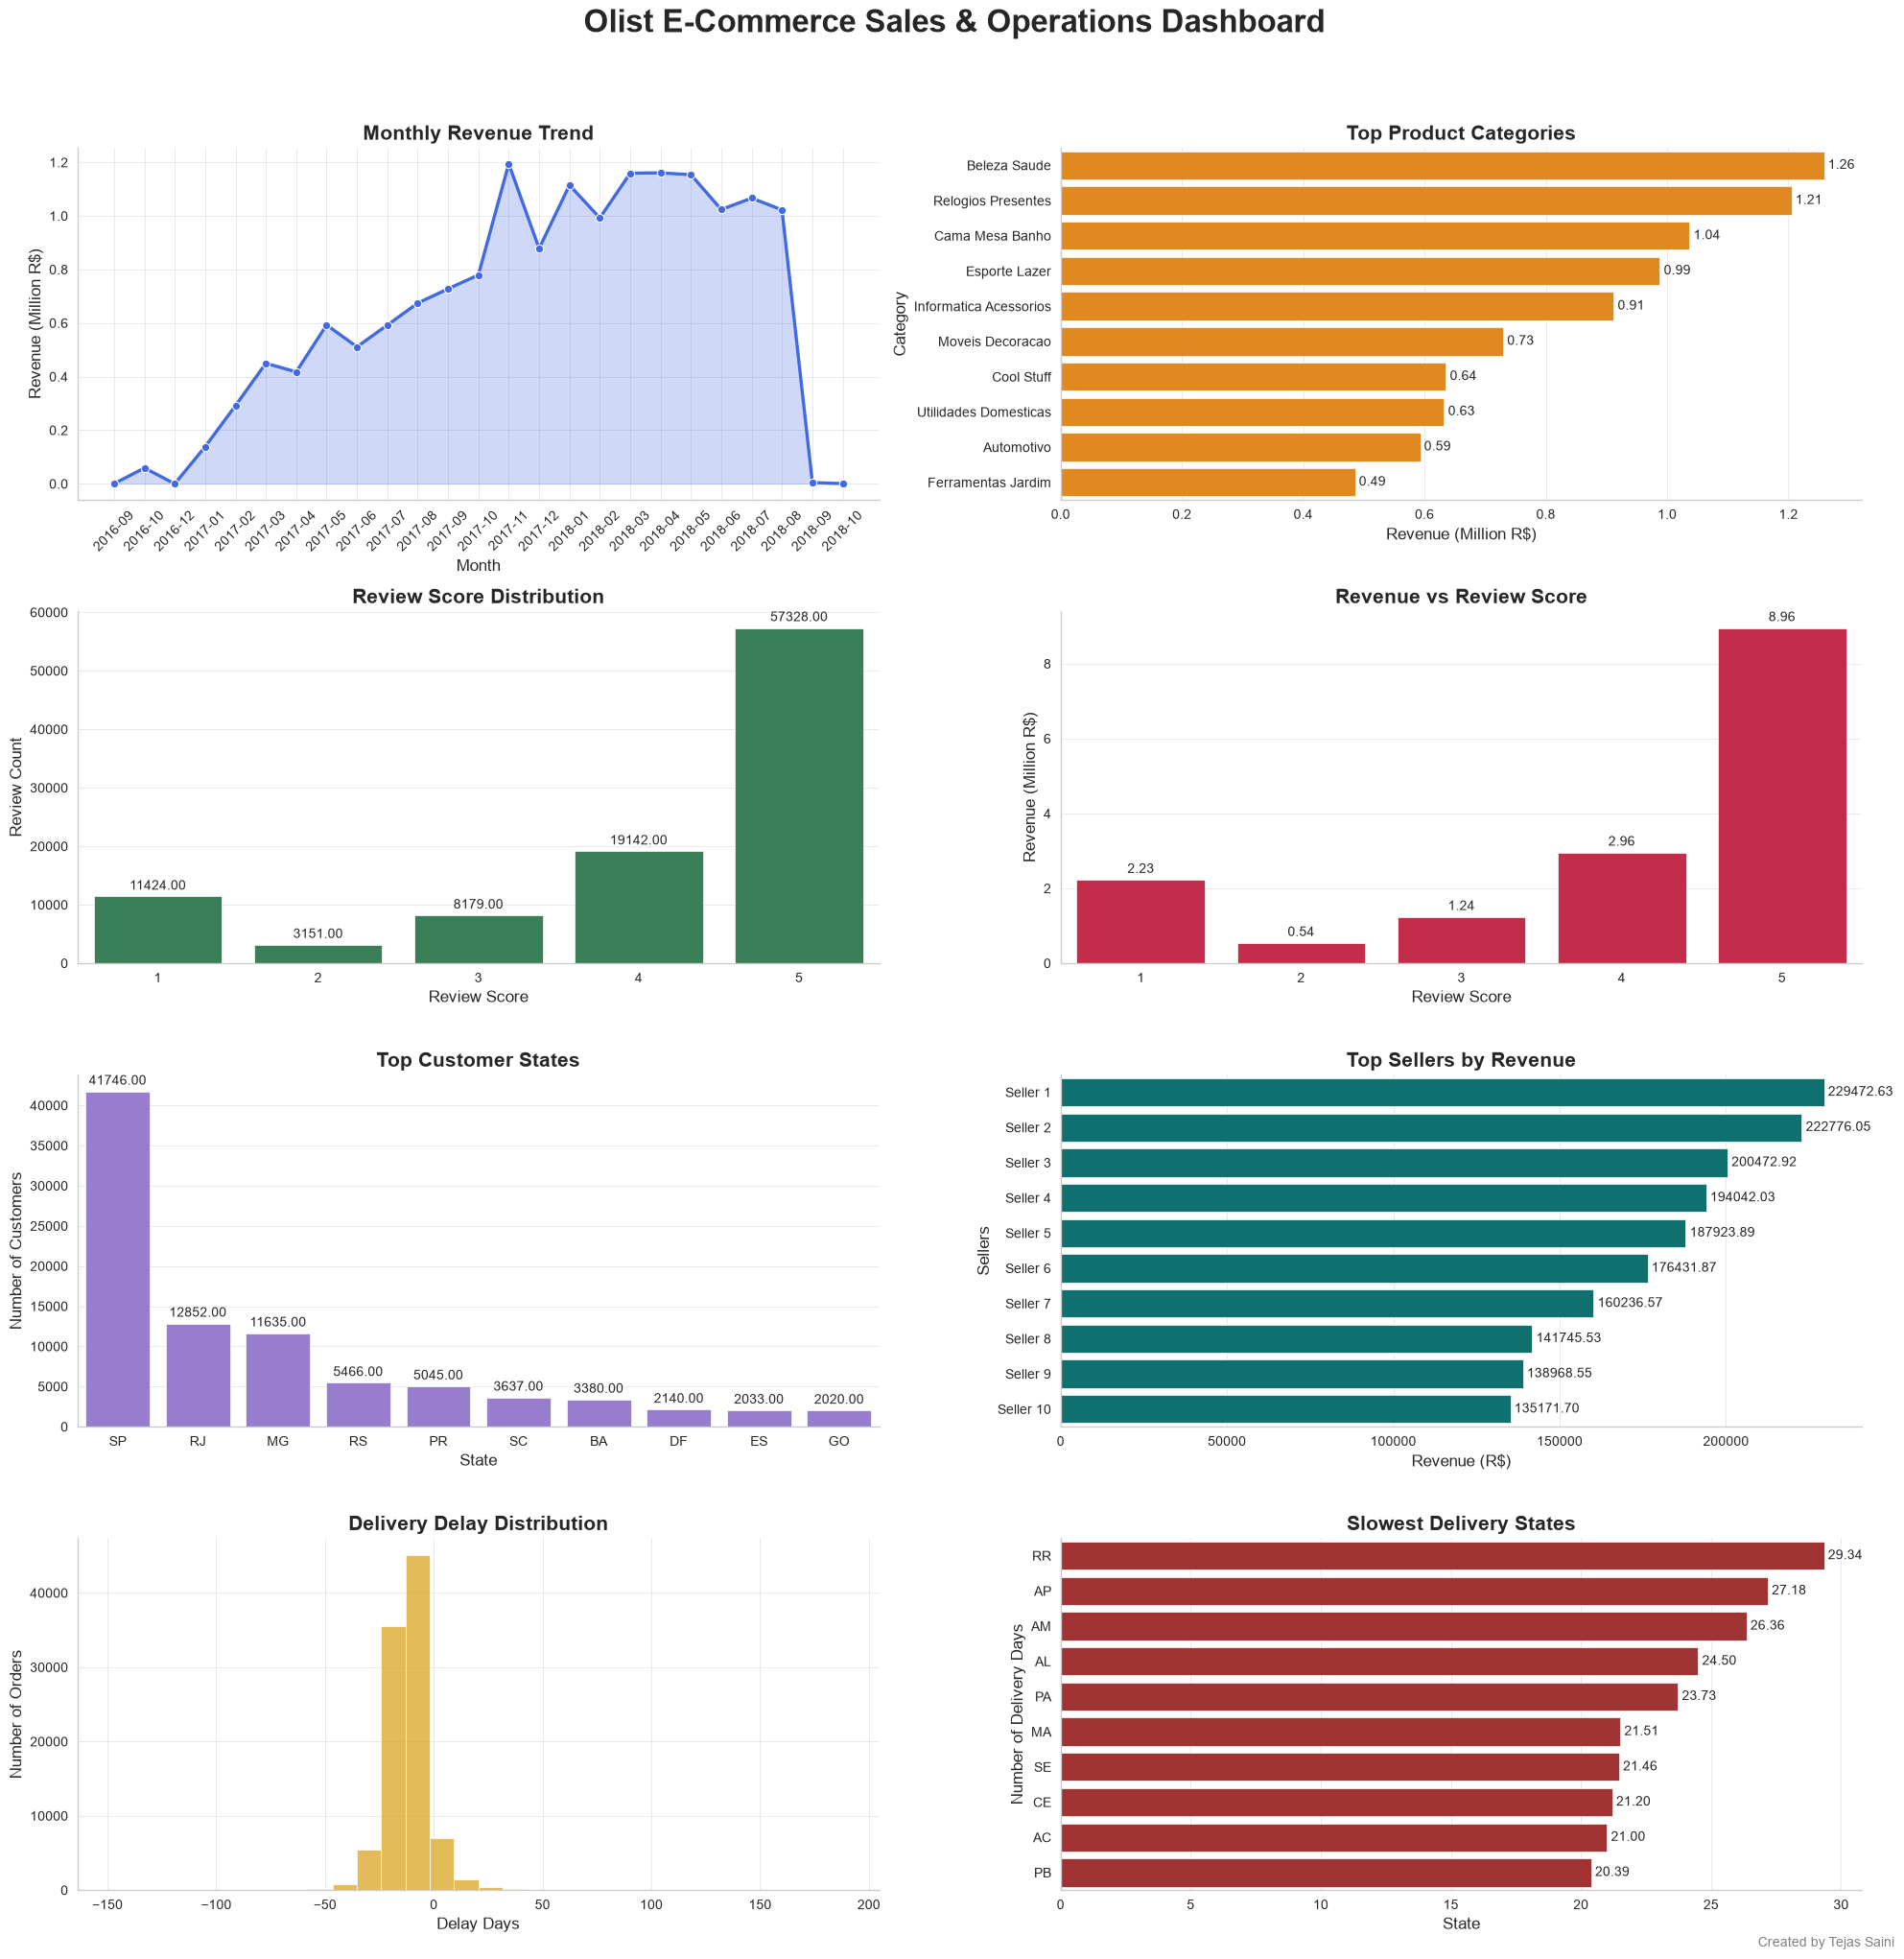

In [94]:
#DASHBOARD

fig,axes=plt.subplots(4,2,figsize=(20,20))

plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["grid.linewidth"] = 0.5


sns.set_style("whitegrid")

fig.suptitle(
    "Olist E-Commerce Sales & Operations Dashboard",
    fontsize=24,
    fontweight="bold",
    y=1.01
)

fig.text(
    0.99,
    0.0001,
    "Created by Tejas Saini",
    ha="right",
    fontsize=10,
    color="gray"
)


#CHART 1:

sns.lineplot(x="MONTH", y="MONTHLY_REVENUE",data=revenue_df,
             marker="o",color="royalblue",
             linewidth=2.4,ax=axes[0,0])

axes[0,0].fill_between(revenue_df["MONTH"],revenue_df["MONTHLY_REVENUE"],
                       color="royalblue",alpha=0.25)


axes[0,0].set_title("Monthly Revenue Trend",fontsize=15,
    fontweight="bold")

axes[0,0].set_xlabel("Month",fontsize=12)
axes[0,0].tick_params(axis="x", rotation=45)

axes[0,0].set_ylabel("Revenue (Million R$)",fontsize=12)


sns.despine()


#CHART 2:
category_df = category_df.sort_values("REVENUE_FROM_CATEGORY", ascending=False).head(10)
category_df["PRODUCT_CATEGORY_NAME"]=category_df["PRODUCT_CATEGORY_NAME"].str.replace("_"," ")

ax=sns.barplot(
    data=category_df,
    x="REVENUE_FROM_CATEGORY",
    y="PRODUCT_CATEGORY_NAME",
    ax=axes[0,1],
    color="darkorange"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[0,1].set_title("Top Product Categories",fontsize=15,
    fontweight="bold")
axes[0,1].set_xlabel("Revenue (Million R$)",fontsize=12)
axes[0,1].set_ylabel("Category",fontsize=12)

sns.despine()


#CHART 3:

ax=sns.barplot(
    data=review_df,
    x="REVIEW_SCORE",
    y="REVIEW_COUNT",
    ax=axes[1,0],
    color="seagreen"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[1,0].set_title("Review Score Distribution",fontsize=15,
    fontweight="bold")
axes[1,0].set_xlabel("Review Score",fontsize=12)
axes[1,0].set_ylabel("Review Count",fontsize=12)

sns.despine()


#CHART 4:
ax=sns.barplot(
    data=revenue_vs_review_df,
    x="REVIEW_SCORE",
    y="REVENUE",
    ax=axes[1,1],
    color="crimson"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[1,1].set_title("Revenue vs Review Score",fontsize=15,
    fontweight="bold")
axes[1,1].set_xlabel("Review Score",fontsize=12)
axes[1,1].set_ylabel("Revenue (Million R$)",fontsize=12)

sns.despine()


#CHART 5:

customer_distribution_by_state_df = customer_distribution_by_state_df.sort_values(
    "NUMBER_OF_CUSTOMERS",
    ascending=False
).head(10)

ax=sns.barplot(
    data=customer_distribution_by_state_df,
    x="CUSTOMER_STATE",
    y="NUMBER_OF_CUSTOMERS",
    ax=axes[2,0],
    color="mediumpurple"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[2,0].set_title("Top Customer States",fontsize=15,
    fontweight="bold")
axes[2,0].set_xlabel("State",fontsize=12)
axes[2,0].set_ylabel("Number of Customers",fontsize=12)

sns.despine()


#CHART 6:

top_sellers_by_revenue_df = top_sellers_by_revenue_df.sort_values(
    "REVENUE_BY_SELLER",
    ascending=False
).head(10)

top_sellers_by_revenue_df["Rank"] = [
    f"Seller {i}" for i in range(1, len(top_sellers_by_revenue_df)+1)
]

ax=sns.barplot(
    data=top_sellers_by_revenue_df,
    x="REVENUE_BY_SELLER",
    y="Rank",
    ax=axes[2,1],
    color="teal"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[2,1].set_title("Top Sellers by Revenue",fontsize=15,
    fontweight="bold")
axes[2,1].set_ylabel("Sellers",fontsize=12)
axes[2,1].set_xlabel("Revenue (R$)",fontsize=12)

sns.despine()

#CHART 7:

sns.histplot(
    delivery_delay_distribution_df["DELAY_DAYS"],
    bins=30,
    ax=axes[3,0],
    color="goldenrod"
)

axes[3,0].set_title("Delivery Delay Distribution",fontsize=15,
    fontweight="bold")
axes[3,0].set_xlabel("Delay Days",fontsize=12)
axes[3,0].set_ylabel("Number of Orders",fontsize=12)

sns.despine()


#CHART 8:

ax=sns.barplot(
    data=slowest_delivery_states_df,
    x="NUMBER_OF_DELIVERY_DAYS",
    y="CUSTOMER_STATE",
    ax=axes[3,1],
    color="firebrick"
)
ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

axes[3,1].set_title("Slowest Delivery States",fontsize=15,
    fontweight="bold")
axes[3,1].set_xlabel("State",fontsize=12)
axes[3,1].set_ylabel("Number of Delivery Days",fontsize=12)

sns.despine()


plt.tight_layout(rect=[0,0,1,0.98])

plt.savefig(
    "../images/dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()